In [2]:
import numpy as np
import pandas as pd
import math
from joblib import dump, load

from src.sensitivity_analysis import run_sensitivity_analysis, save_sensitivity_analysis
from src.calibration import run_calibration, save_calibration
from src.visualization import plot_sensitivity_analysis, plot_calibration, plot_results, barplot_results

In [3]:
# data loading
data = pd.read_csv("processed_data/data.csv")
T = np.load('processed_data/temperature.npy')
N = np.shape(data)[0]
data = data.drop(data.columns[0],axis=1)

# densities
years = data.year
juveniles = data.juveniles_density/2 # half because we only consider females
adult_fems = data.adult_fems_density
tot_crabs = data.total_crabs_density

time_ode = np.arange(1,N*12+1)

T_ode = np.reshape(T,(1,-1))[0]

# initial conditions
X0_state = np.transpose([juveniles[0],adult_fems[0]])

# training set
years_train = list(data.year[:math.floor(0.8*N)])
juveniles_train = data.juveniles_density[:math.floor(0.8*N)]/2
adult_fems_train = data.adult_fems_density[:math.floor(0.8*N)]
time_ode_train = np.arange(1,math.floor(0.8*N)*12+1)
T_ode_train = T_ode[:math.floor(0.8*N)*12]

# validation set
years_val = list([x for x in data.year[math.floor(0.8*N):]])
juveniles_val = [x for x in juveniles[math.floor(0.8*N):]/2]
adult_fems_val = [x for x in data.adult_fems_density[math.floor(0.8*N):]]
time_ode_val = np.arange(math.floor(0.8*N)*12+1,N*12+1)
T_ode_val = [x for x in T_ode[math.floor(0.8*N)*12:N*12+1]]

# initial conditions
X0_train =[juveniles_train[0],adult_fems_train[0]]
X0_val = [juveniles_val[0],adult_fems_val[0]]

In [4]:
# sensitivity analisys performed with:
# Pianosi, F., Sarrazin, F., Wagener, T. (2015), A Matlab toolbox for Global Sensitivity Analysis, Environmental Modelling & Software, 70, 80-85, 
# doi: 10.1016/j.envsoft.2015.04.009.


# threshold for selecting critical parameters
thresh = 0.03

# either run this (takes approx 1 hour):
#SA_out = run_sensitivity_analysis(time_ode, T_ode, X0_state, juveniles, adult_fems, thresh)
#save_sensitivity_analysis(SA_out,'outputs/sensitivity_analysis_out.joblib')

# or load already saved ouputs:
SA_out = load('outputs/sensitivity_analysis_out.joblib')

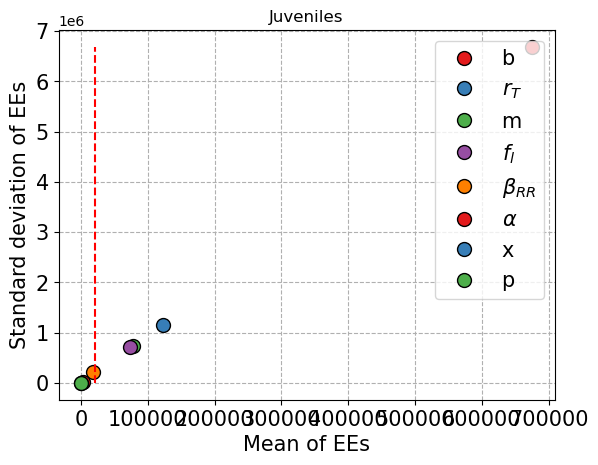

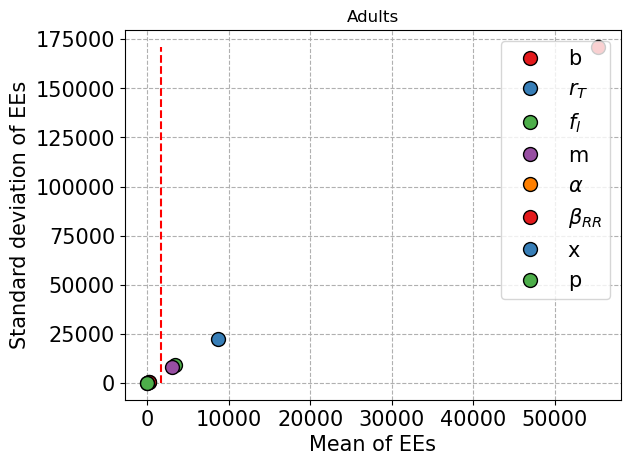

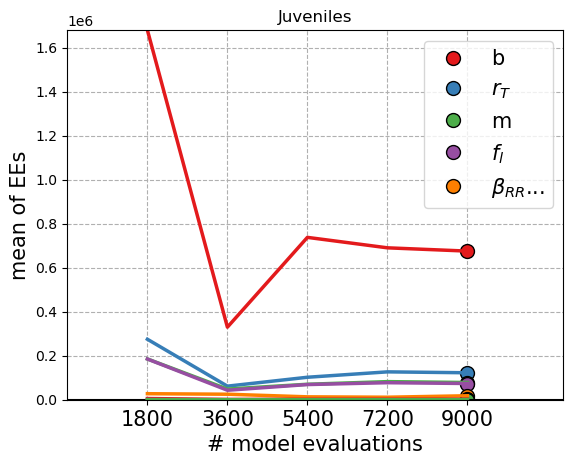

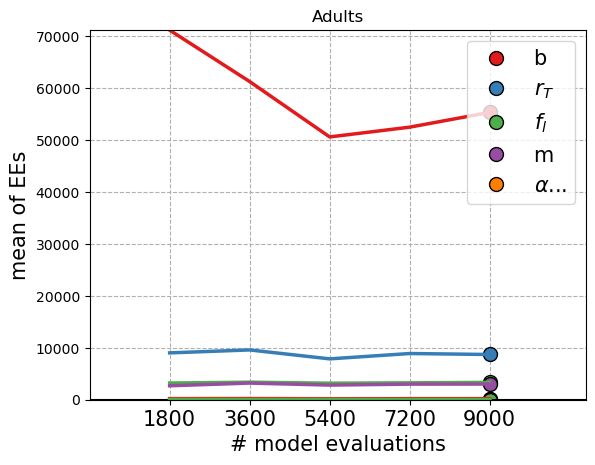

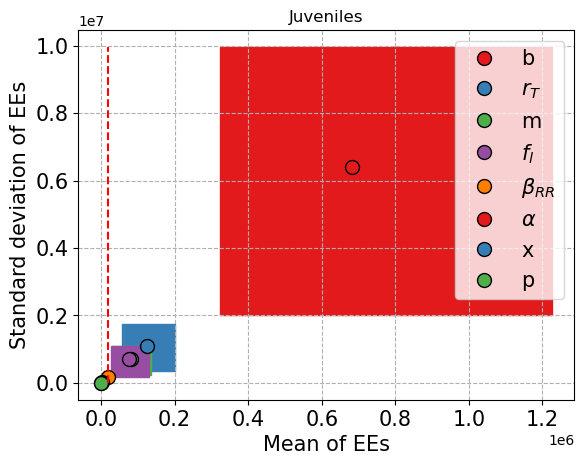

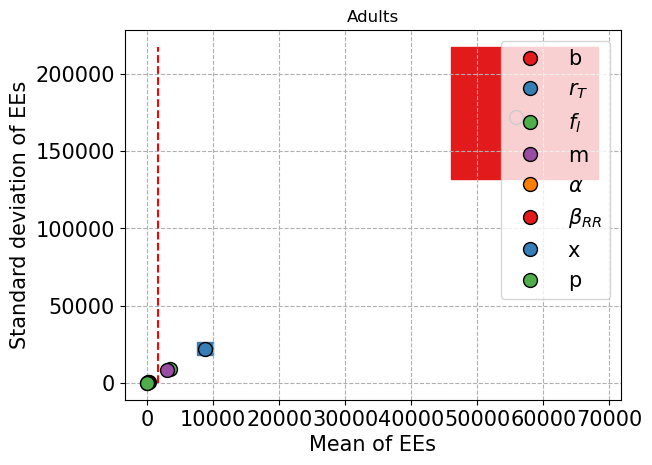

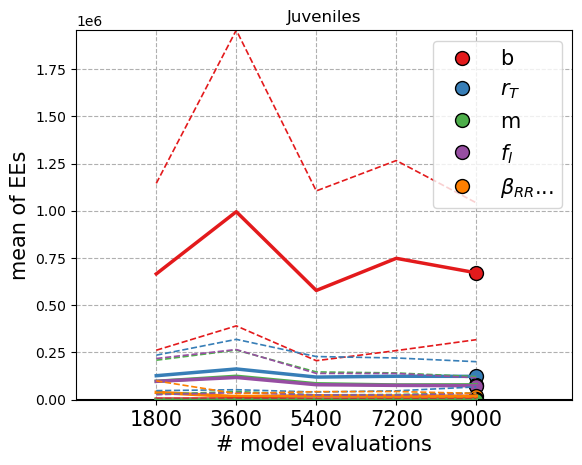

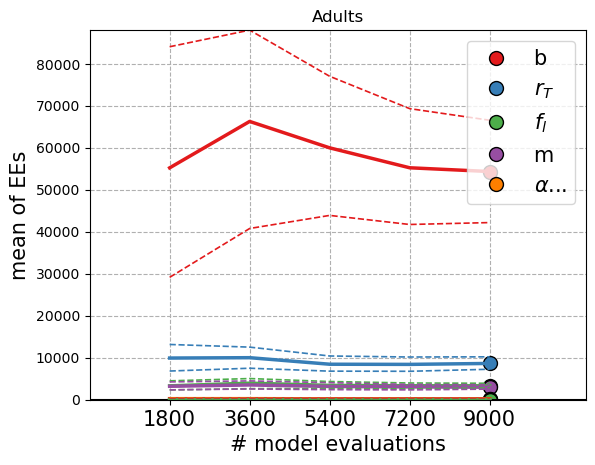

In [9]:
plot_sensitivity_analysis(SA_out)

In [6]:
# calibration

# parameters selection (threshold = 3%)
max_mi_J = max(SA_out['mi_m_J'])
max_mi_A = max(SA_out['mi_m_A'])
selected_parameters_indices = np.union1d(np.where(SA_out['mi_m_J']>=thresh*max_mi_J)[0],np.where(SA_out['mi_m_A']>=thresh*max_mi_A)[0])

# either run this (takes approx 2 hour):
#cal_out = run_calibration(time_ode_train, X0_train, juveniles_train, adult_fems_train, T_ode_train, selected_parameters_indices)
#save_calibration(cal_out,'outputs/calibration_out.joblib')

# or load alreay saved outputs:
cal_out = load('outputs/calibration_out.joblib')

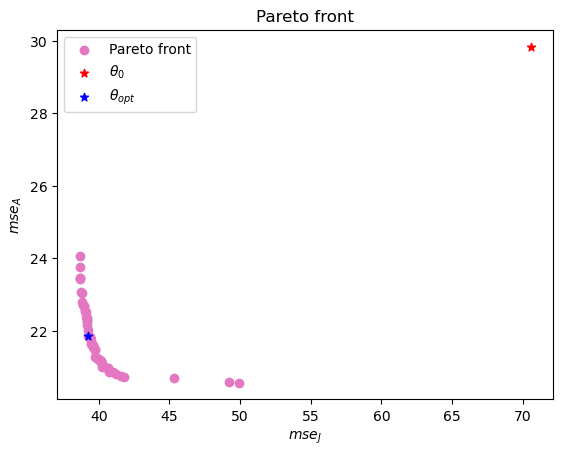

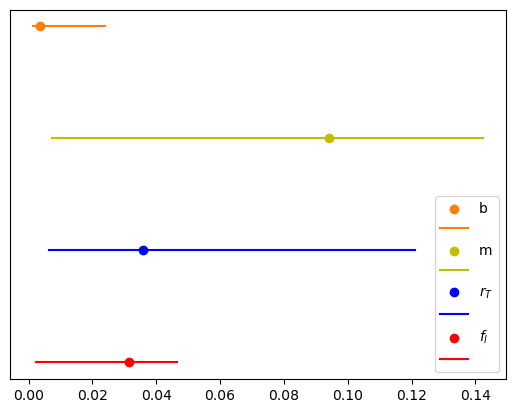

In [7]:
plot_calibration(cal_out)

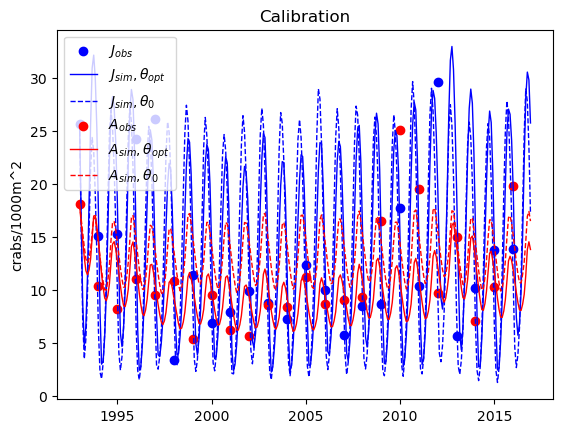

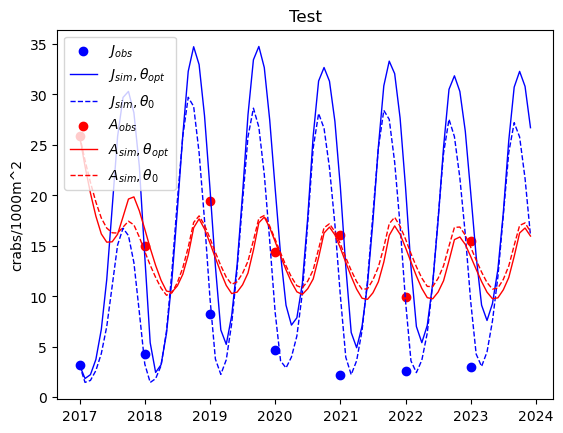

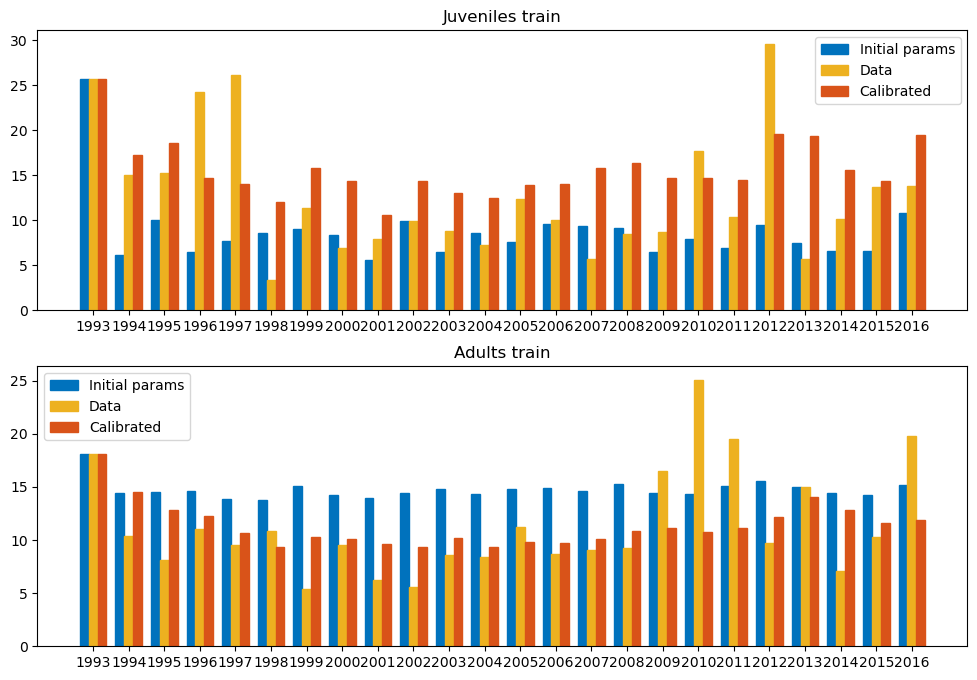

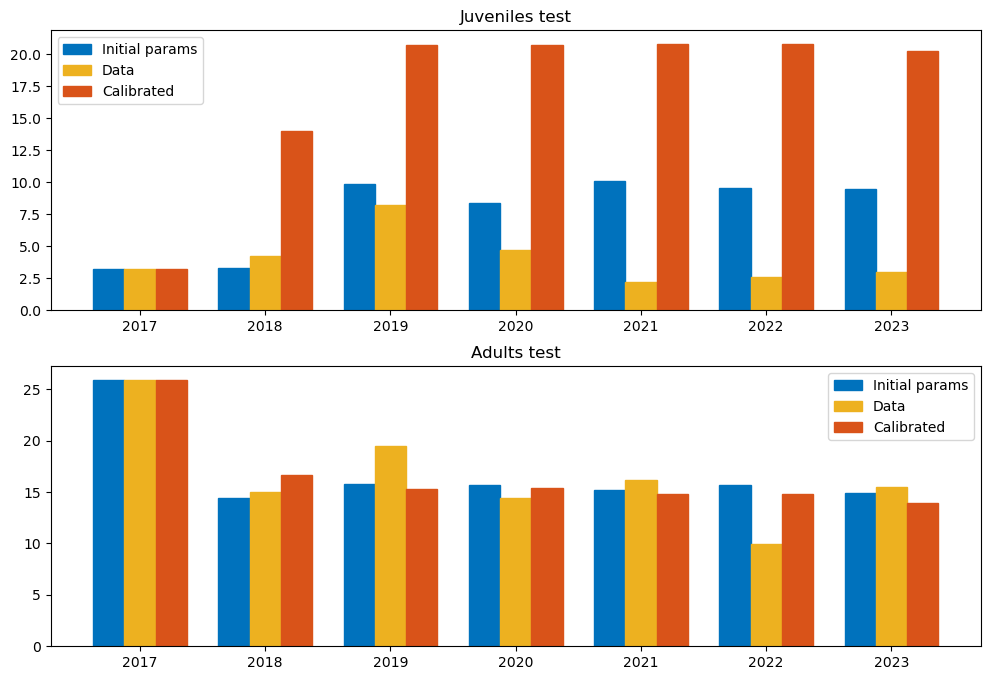

In [8]:
params_opt = cal_out['params_opt']
plot_results(T_ode_train, time_ode_train, years_train, X0_train, juveniles_train, adult_fems_train, T_ode_val, time_ode_val, years_val, X0_val, juveniles_val, adult_fems_val, params_opt)
barplot_results(T_ode_train, time_ode_train, years_train, X0_train, juveniles_train, adult_fems_train, T_ode_val, time_ode_val, years_val, X0_val, juveniles_val, adult_fems_val, params_opt)